In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/zomato.csv', on_bad_lines='skip')

print("--- DATA SUMMARY --- ")
df.info()


print("\n--- FIRST 3 ROWS ---")
display(df.head(3))


print("\nInitial DataFrame loaded. Data cleaning will proceed in the next cell.")

--- DATA SUMMARY --- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      55992 non-null  object
 1   name                         55991 non-null  object
 2   online_order                 55993 non-null  object
 3   book_table                   55963 non-null  object
 4   rate                         48051 non-null  object
 5   votes                        55947 non-null  object
 6   phone                        54847 non-null  object
 7   location                     55910 non-null  object
 8   rest_type                    55680 non-null  object
 9   dish_liked                   27157 non-null  object
 10  cuisines                     55856 non-null  object
 11  approx_cost(for two people)  55662 non-null  object
 12  listed_in(type)              52160 non-null  object
dtypes: object

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet



Initial DataFrame loaded. Data cleaning will proceed in the next cell.


## Data Cleaning

In [15]:
print("Step 2: Cleaning data and removing text glitches... Please wait.")

# 1. Clean the 'rate' column safely
def clean_rate(value):
    if pd.isna(value):
        return np.nan
    value = str(value).split('/')[0].strip()
    try:
        return float(value)
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)

# 2. Find the correct cost column name automatically and clean it
# (This fixes the column name error by checking what your file actually uses)
cost_col = 'approx_cost' if 'approx_cost' in df.columns else 'approx_cost(for two people)'

def clean_cost(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace(',', '').strip()
    try:
        return float(value)
    except ValueError:
        return np.nan

# Clean and make sure it creates/overwrites the standardized 'approx_cost' column
df['approx_cost'] = df[cost_col].apply(clean_cost)

# 3. Clean the 'votes' column safely by forcing text strings to NaN
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# 4. Fill missing values with calculated medians so visualizations don't break
df['rate'] = df['rate'].fillna(df['rate'].median())
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())
df['votes'] = df['votes'].fillna(df['votes'].median())
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

print("\nData Cleaning Complete! Verified numeric columns:")
print(df[['rate', 'approx_cost', 'votes']].dtypes)

Step 2: Cleaning data and removing text glitches... Please wait.

Data Cleaning Complete! Verified numeric columns:
rate           float64
approx_cost    float64
votes          float64
dtype: object


## Visualizations

In [16]:
import numpy as np

print("Cleaning data with smart text handling... Please wait.")


def clean_rate(value):
    if pd.isna(value):
        return np.nan


    value = str(value).split('/')[0].strip()

    try:

        return float(value)
    except ValueError:

        return np.nan

df['rate'] = df['rate'].apply(clean_rate)


def clean_cost(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace(',', '').strip()
    try:
        return float(value)
    except ValueError:
        return np.nan

df['approx_cost'] = df['approx_cost(for two people)'].apply(clean_cost)

df['rate'] = df['rate'].fillna(df['rate'].median())
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

print("\nData Cleaning Complete! Your clean data types are:")
print(df[['rate', 'approx_cost']].dtypes)


Cleaning data with smart text handling... Please wait.

Data Cleaning Complete! Your clean data types are:
rate           float64
approx_cost    float64
dtype: object


Step 3: Generating charts... Please look below.


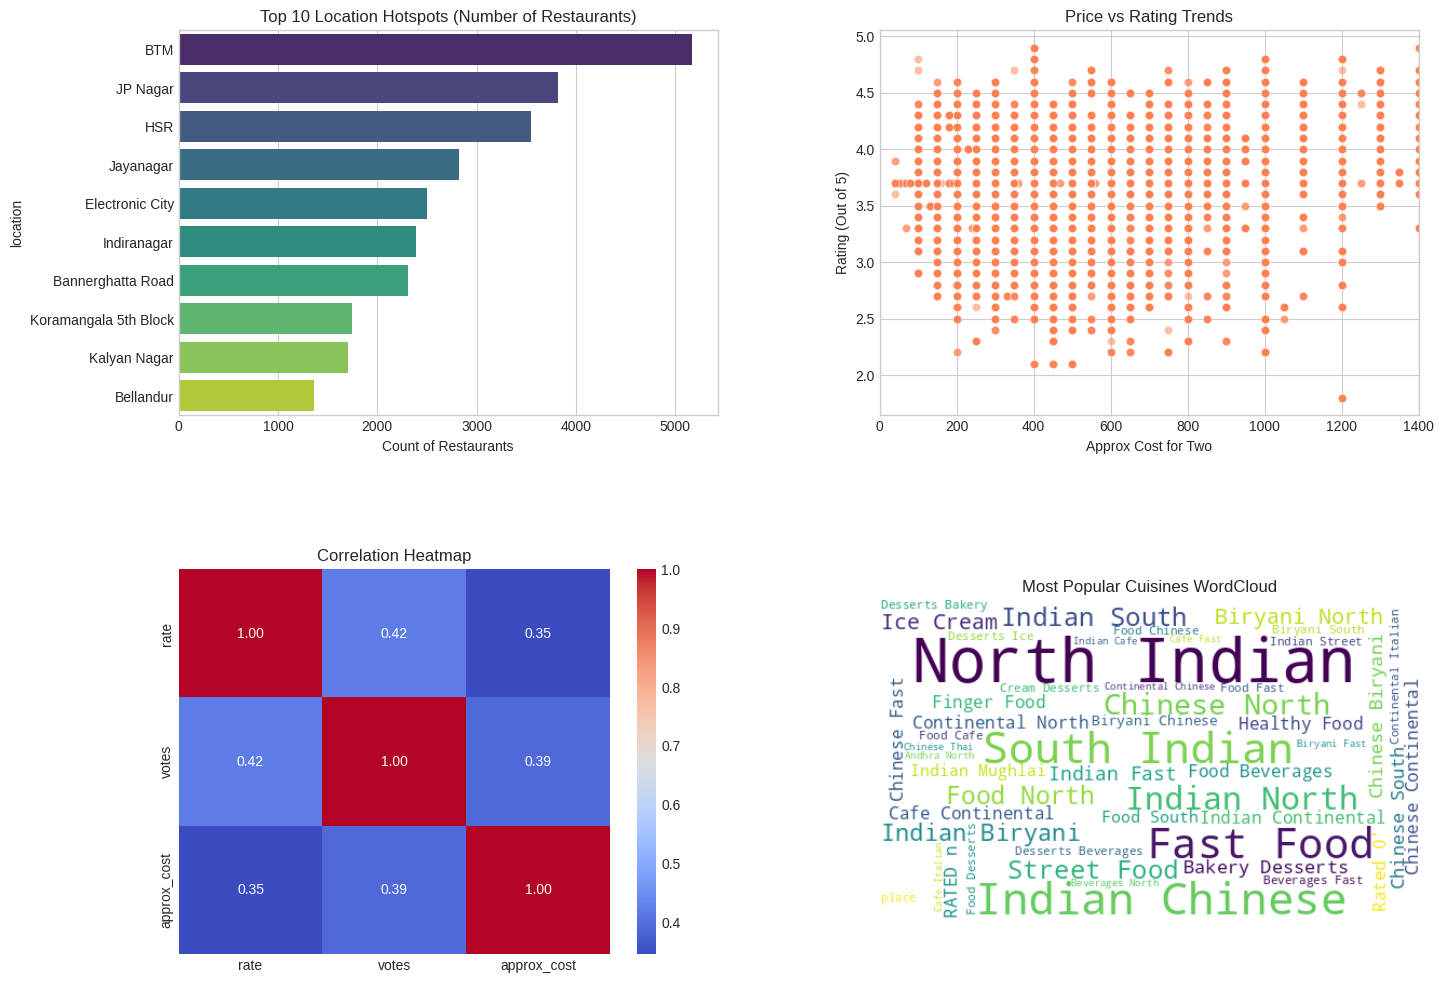

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


print("Step 3: Generating charts... Please look below.")

# Set up the plotting grid style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Location Hotspots Bar Chart (Fixed: Added hue mapping to resolve the FutureWarning)
top_locations = df['location'].value_counts().head(10)
sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    ax=axes[0, 0],
    hue=top_locations.index,
    legend=False,
    palette='viridis'
)
axes[0, 0].set_title('Top 10 Location Hotspots (Number of Restaurants)')
axes[0, 0].set_xlabel('Count of Restaurants')

# 2. Price vs Rating Scatter Plot
sns.scatterplot(data=df, x='approx_cost', y='rate', alpha=0.5, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Price vs Rating Trends')
axes[0, 1].set_xlabel('Approx Cost for Two')
axes[0, 1].set_ylabel('Rating (Out of 5)')
axes[0, 1].set_xlim(0, df['approx_cost'].quantile(0.95))

# 3. Correlation Heatmap
corr_matrix = df[['rate', 'votes', 'approx_cost']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap')

# 4. WordCloud for Popular Cuisines
cuisine_text = " ".join(c for c in df['cuisines'].dropna())
wordcloud = WordCloud(width=500, height=300, background_color='white', max_words=50).generate(cuisine_text)
axes[1, 1].imshow(wordcloud, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('Most Popular Cuisines WordCloud')

plt.show()